In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential  # Space was missing between "models" and "import"
from tensorflow.keras.layers import Dense
from google.colab import auth
import gspread
from google.auth import default


In [ ]:
auth.authenticate_user()
creds,_ = default()
gc = gspread.authorize (creds)
worksheet = gc.open('DEEP LEARNING ').sheet1
data = worksheet.get_all_values()


In [ ]:
dataset1 = pd.DataFrame(data[1:], columns=data[0])
dataset1 = dataset1.astype({'X': 'float'})
dataset1 = dataset1.astype({'Y': 'float'})
dataset1.head()


,X,Y
0,1.0,11.0
1,2.0,21.0
2,3.0,31.0
3,4.0,41.0
4,5.0,51.0


In [ ]:
X = dataset1[['X']].values
y = dataset1[['Y']].values
#X
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size = 0.33, random_state = 33)
Scaler = MinMaxScaler()
Scaler.fit(X_train)

MinMaxScaler()

In [ ]:
X_train1 = Scaler.transform(X_train)
ai_brain = Sequential ([
Dense (8, activation = 'relu'),
Dense (10, activation = 'relu'),
Dense (1)
])
ai_brain.compile(optimizer = 'rmsprop', loss = 'mse')
ai_brain.fit(X_train1, y_train, epochs =3000)

Streaming output truncated to the last 5000 lines.
Epoch 501/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 12222.8896
Epoch 502/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 12219.7402
Epoch 503/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 12216.5840
Epoch 504/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 12213.4209
Epoch 505/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 12210.2480
Epoch 506/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 12207.0674
Epoch 507/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 12203.8770
Epoch 508/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 12200.6816
Epoch 509/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 12197.4756
Epoch 510/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 12194.2646
Epoch 511/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 12191.0430
Epoch 512/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 12187.8145
Epoch 513/3000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 12184.5771
Epoch 514/300

<Axes: >

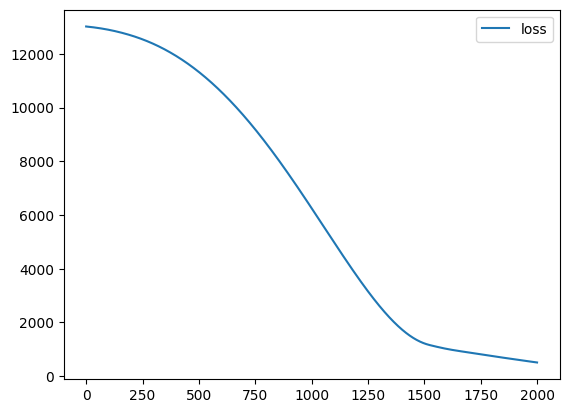

In [ ]:
# KRISHNARAJ D
loss_df= pd.DataFrame(ai_brain.history.history)
loss_df.plot()

In [ ]:
X_test1=Scaler.transform(X_test)
ai_brain.evaluate(X_test1, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 591.1736


591.1736450195312

In [ ]:
X_n1=[[7]]
X_n1_1=Scaler.transform(X_n1)
ai_brain.predict(X_n1_1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[89.22974]], dtype=float32)